In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import random

In [5]:
from xml.etree import ElementTree

In [2]:
random.seed(4354678)

In [29]:
img_list = os.listdir("../../dataset/final_voc/img")

In [31]:
def obj_size(obj):
    bbox = obj.find('bndbox')
    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)
    return (ymax - ymin) * (xmax - xmin)
def get_biggest(obj_list):
    new_obj_list = []
    for obj in obj_list:
        new_obj_list.append(obj)
    if len(new_obj_list) == 0:
        return None
    else:
        new_obj_list.sort(reverse=True, key=obj_size)
    return new_obj_list[0]

In [32]:
mask_dir = "../../dataset/final_voc/mask"
dest_dir = "../../dataset/final_voc/obj"

In [33]:
# crop the img to only include biggest obj
for fn in img_list:
    
    img = cv2.imread("../../../VOCdevkit/VOC2012/JPEGImages/" + fn)
    tree = ElementTree.parse(os.path.join('../../../VOCdevkit/VOC2012/Annotations/', fn.split('.')[0] + '.xml'))
    obj_list = tree.getroot().findall("object")
    biggest_obj = get_biggest(obj_list)
    
    # find the bounding box
    bbox = biggest_obj.find('bndbox')
    xmin = int(bbox.find('xmin').text)
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)
    xmin, ymin, xmax, ymax = [int(x) for x in [xmin, ymin, xmax, ymax]]    
    
    # crop the img by the bbox
    cropped = np.zeros_like(img)
    cropped[ymin:ymax, xmin:xmax] = img[ymin:ymax, xmin:xmax]
    
    # Apply mask and pad to 500x500
    mask = cv2.imread("../../dataset/final_voc/mask/" + fn)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    cropped = cv2.bitwise_and(cropped,cropped,mask=mask)    
    bottom = 500 - cropped.shape[0]
    right = 500 - cropped.shape[1]
    cropped = cv2.copyMakeBorder(cropped, top=0, bottom=bottom, left=0, right=right,borderType=cv2.BORDER_CONSTANT, value=[0,0,0])

    # Move obj to top left
    grey = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    mask = grey > 0
    ys, xs = np.where(mask)
    h, w = mask.shape
    top_dist = ys.min()                 # distance from top border
    bottom_dist = h - 1 - ys.max()      # distance from bottom border
    left_dist = xs.min()                # distance from left border
    right_dist = w - 1 - xs.max()       # distance from right border
    cropped = np.vstack((cropped[ys.min():],cropped[:ys.min()]))
    cut = xs.min() - 1
    left = cropped[:, :cut]
    right = cropped[:, cut:]
    cropped = np.hstack((right, left))
    
    cv2.imwrite("../../dataset/final_voc/obj_normed/" + fn, cropped,[int(cv2.IMWRITE_JPEG_QUALITY), 100])

    # Resize randomly    
    grey = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(grey)
    cropped = cropped[:ys.max() + 1,:xs.max() + 1]
    while True:
        scale = random.uniform(0.5, 1.5)
        new_w = int(cropped.shape[1] * scale)
        new_h = int(cropped.shape[0] * scale)
        if new_w <= 500 and new_h <= 500:
            break
    resized = cv2.resize(cropped, (new_w, new_h))
    bottom = 500 - resized.shape[0]
    right = 500 - resized.shape[1]
    resized = cv2.copyMakeBorder(resized, top=0, bottom=bottom, left=0, right=right,borderType=cv2.BORDER_CONSTANT, value=[0,0,0])
    
    cv2.imwrite("../../dataset/final_voc/obj_resized/" + fn, resized,[int(cv2.IMWRITE_JPEG_QUALITY), 100])

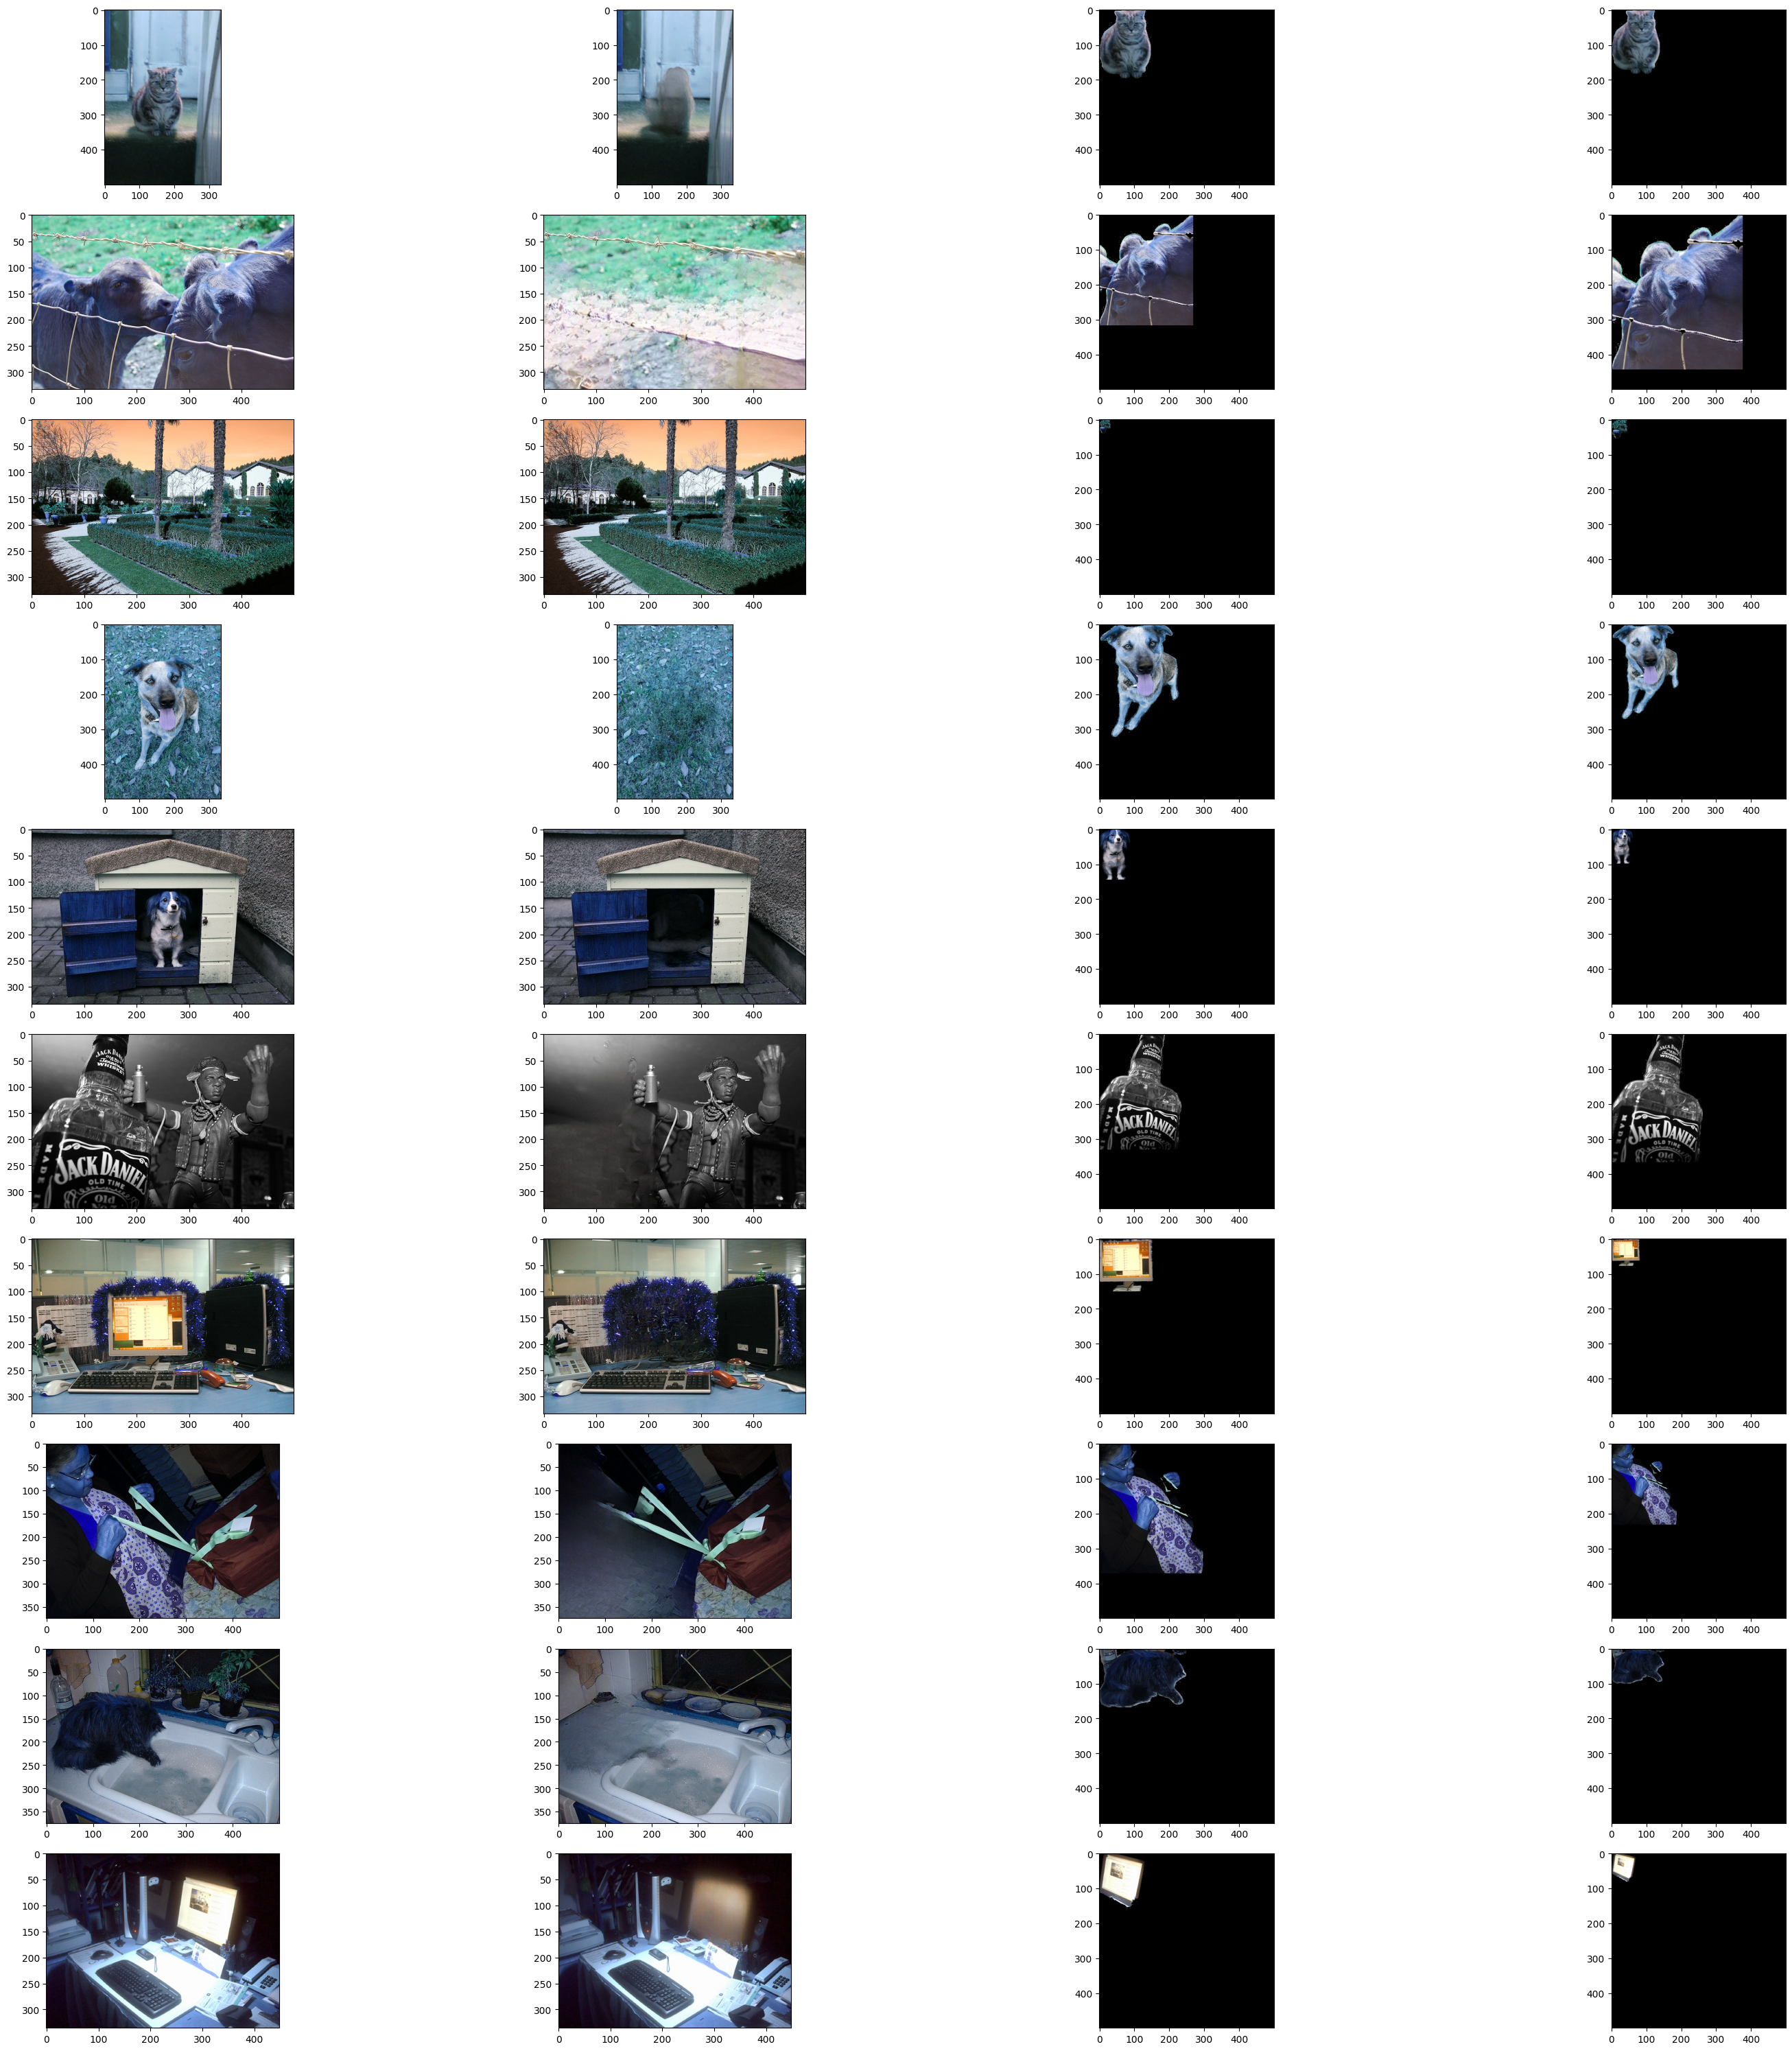

In [34]:
example_images = img_list[450:460]
nrows = len(example_images)
ncols = 4
i = 0

fig, axes = plt.subplots(nrows, ncols, figsize=(30,30))
fig.tight_layout()

for fn in example_images:
    scene = cv2.imread("../../../VOCdevkit/VOC2012/JPEGImages/" + fn)
    empty_scene = cv2.imread("../../dataset/final_voc/img/" + fn)
    obj = cv2.imread("../../dataset/final_voc/obj_normed/" + fn)
    obj_resized = cv2.imread("../../dataset/final_voc/obj_resized/" + fn)

    i += 1
    plt.subplot(nrows, ncols, i)
    plt.imshow(scene)
    
    i +=1 
    plt.subplot(nrows, ncols, i)
    plt.imshow(empty_scene)

    i += 1
    plt.subplot(nrows, ncols, i)
    plt.imshow(obj)

    i += 1
    plt.subplot(nrows, ncols, i)
    plt.imshow(obj_resized)